In [1]:
!apt-get install -y swig build-essential
!pip install stable-baselines3[extra] gymnasium[box2d] openai matplotlib pandas scipy
!pip install gymnasium[classic-control]

'apt-get' is not recognized as an internal or external command,
operable program or batch file.


   ---------------------------------------- 0.0/952.1 kB ? eta -:--:--
   ---------------------- ----------------- 524.3/952.1 kB 7.0 MB/s eta 0:00:01
   ---------------------------------------- 952.1/952.1 kB 2.7 MB/s  0:00:00
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------  1.3/1.3 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------- 1.3/1.3 MB 4.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------------------------------- -- 2.4/2.5 MB 13.3 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 11.4 MB/s  0:00:00
   ---------------------------------------- 0.0/3.5 MB ? eta -:--:--
   ------------------ --------------------- 1.6/3.5 MB 6.9 MB/s eta 0:00:01
   ---------------------------------------- 3.5/3.5 MB 8.2 MB/s  0:00:00
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ------- -------------------------------- 2

In [2]:
import gymnasium as gym
import stable_baselines3 as sb3
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os, pickle, warnings
warnings.filterwarnings("ignore")

print(f"✅ Gymnasium:        {gym.__version__}")
print(f"✅ Stable Baselines: {sb3.__version__}")
print(f"✅ PyTorch:          {torch.__version__}")
print(f"✅ CUDA available:   {torch.cuda.is_available()}")

# ── Check all environments ────────────────────────────────────────────────────
ENVS_TO_USE = {
    "CartPole-v1"    : 100_000,
    "LunarLander-v3" : 250_000,
    "MountainCar-v0" : 200_000,
}

print("\n── Environment Check ──────────────────────────────────")
all_ok = True
for env_id in ENVS_TO_USE:
    try:
        env = gym.make(env_id)
        obs, _ = env.reset()
        print(f"  ✅ {env_id:25s} obs shape: {obs.shape}")
        env.close()
    except Exception as e:
        print(f"  ❌ {env_id:25s} ERROR: {e}")
        all_ok = False

if all_ok:
    print("\n🎉 All environments OK! Safe to proceed.")
else:
    print("\n⚠️  Fix errors above before proceeding.")

✅ Gymnasium:        1.2.3
✅ Stable Baselines: 2.7.1
✅ PyTorch:          2.12.0.dev20260321+cu128
✅ CUDA available:   True

── Environment Check ──────────────────────────────────
  ✅ CartPole-v1               obs shape: (4,)
  ✅ LunarLander-v3            obs shape: (8,)
  ✅ MountainCar-v0            obs shape: (2,)

🎉 All environments OK! Safe to proceed.


In [3]:
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.vec_env import DummyVecEnv

os.makedirs("results", exist_ok=True)
os.makedirs("models",  exist_ok=True)

# ── Reward Logger ─────────────────────────────────────────────────────────────
class RewardLogger(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_rewards = []
        self.episode_lengths = []
        self._current_reward = 0
        self._current_length = 0

    def _on_step(self):
        self._current_reward += self.locals["rewards"][0]
        self._current_length += 1
        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_reward)
            self.episode_lengths.append(self._current_length)
            self._current_reward = 0
            self._current_length = 0
        return True

# ── Custom Reward Wrapper ─────────────────────────────────────────────────────
class CustomRewardWrapper(gym.Wrapper):
    def __init__(self, env, reward_fn):
        super().__init__(env)
        self.reward_fn = reward_fn
        self._last_obs = None

    def reset(self, **kwargs):
        obs, info      = self.env.reset(**kwargs)
        self._last_obs = obs
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        try:
            new_reward = float(self.reward_fn(
                self._last_obs, action, reward, obs, terminated, info
            ))
        except Exception as e:
            print(f"⚠️  Reward fn error: {e} — using default")
            new_reward = reward
        new_reward     = np.clip(new_reward, -10.0, 10.0)
        self._last_obs = obs
        return obs, new_reward, terminated, truncated, info

# ── Train Agent ───────────────────────────────────────────────────────────────
def train_agent(env_id, total_timesteps=100_000, seed=42, reward_fn=None, label="agent"):
    def make_env():
        env = gym.make(env_id)
        if reward_fn is not None:
            env = CustomRewardWrapper(env, reward_fn)
        return Monitor(env)

    env      = DummyVecEnv([make_env])
    callback = RewardLogger()

    model = PPO(
        "MlpPolicy", env,
        verbose       = 0,
        seed          = seed,
        learning_rate = 3e-4,
        n_steps       = 2048,
        batch_size    = 64,
        n_epochs      = 10,
        gamma         = 0.99,
        gae_lambda    = 0.95,
        clip_range    = 0.2,
    )
    print(f"    [{label}] seed={seed} | {total_timesteps:,} steps...")
    model.learn(total_timesteps=total_timesteps, callback=callback)
    env.close()
    return model, callback.episode_rewards

# ── Multi-seed Runner ─────────────────────────────────────────────────────────
def run_experiment(env_id, total_timesteps, reward_fn=None, label="agent", seeds=[0,1,2,3,4]):
    all_rewards = []
    for seed in seeds:
        _, rewards = train_agent(
            env_id, total_timesteps,
            seed=seed, reward_fn=reward_fn,
            label=f"{label}_s{seed}"
        )
        all_rewards.append(rewards)
    return all_rewards

# ── Helpers ───────────────────────────────────────────────────────────────────
def smooth(rewards, window=20):
    if len(rewards) < window:
        return rewards
    return np.convolve(rewards, np.ones(window)/window, mode='valid').tolist()

def get_stats(all_rewards, last_n=10):
    finals = []
    for rewards in all_rewards:
        if len(rewards) >= last_n:
            finals.append(np.mean(rewards[-last_n:]))
        elif rewards:
            finals.append(np.mean(rewards))
    if not finals:
        return 0.0, 0.0
    return np.mean(finals), np.std(finals)

print("✅ Infrastructure ready!")

✅ Infrastructure ready!


In [4]:
# ── Uses ENVS_TO_USE defined in Cell 2 ───────────────────────────────────────
SEEDS = [0, 1, 2, 3, 4]

baseline_results = {}

for env_id, steps in ENVS_TO_USE.items():
    print(f"\n{'='*55}")
    print(f"🎮 Baseline: {env_id}")
    results = run_experiment(
        env_id, steps,
        reward_fn = None,
        label     = "baseline",
        seeds     = SEEDS
    )
    baseline_results[env_id] = results
    m, s = get_stats(results)
    print(f"  ✅ Mean final reward: {m:.1f} ± {s:.1f}")

with open("results/baseline_results.pkl", "wb") as f:
    pickle.dump(baseline_results, f)
print("\n💾 Baselines saved!")


🎮 Baseline: CartPole-v1
    [baseline_s0] seed=0 | 100,000 steps...
    [baseline_s1] seed=1 | 100,000 steps...
    [baseline_s2] seed=2 | 100,000 steps...
    [baseline_s3] seed=3 | 100,000 steps...
    [baseline_s4] seed=4 | 100,000 steps...
  ✅ Mean final reward: 500.0 ± 0.0

🎮 Baseline: LunarLander-v3
    [baseline_s0] seed=0 | 250,000 steps...
    [baseline_s1] seed=1 | 250,000 steps...
    [baseline_s2] seed=2 | 250,000 steps...
    [baseline_s3] seed=3 | 250,000 steps...
    [baseline_s4] seed=4 | 250,000 steps...
  ✅ Mean final reward: 136.8 ± 64.2

🎮 Baseline: MountainCar-v0
    [baseline_s0] seed=0 | 200,000 steps...
    [baseline_s1] seed=1 | 200,000 steps...
    [baseline_s2] seed=2 | 200,000 steps...
    [baseline_s3] seed=3 | 200,000 steps...
    [baseline_s4] seed=4 | 200,000 steps...
  ✅ Mean final reward: -200.0 ± 0.0

💾 Baselines saved!


In [6]:
# ── Cell 5: Gemini API Setup ─────────────────────────────────────────────────
!pip install -q google-generativeai

import os

# ── Get API key from environment or fallback ─────────────────────────────────
try:
    # Try Google Colab first
    from google.colab import userdata
    GEMINI_API_KEY = userdata.get("GEMINI_API_KEY")
    print("✅ Gemini API key loaded from Colab Secrets")
except ImportError:
    # Local environment: check environment variable or use fallback
    GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
    if GEMINI_API_KEY:
        print("✅ Gemini API key loaded from environment variable")
    else:
        raise RuntimeError("GEMINI_API_KEY not found. Set it as an environment variable or Colab secret before running.")

# ── Test the key works ────────────────────────────────────────────────────────
import google.generativeai as genai
genai.configure(api_key=GEMINI_API_KEY)

test_model = genai.GenerativeModel("gemini-2.5-flash")
test_resp  = test_model.generate_content("Say OK in one word.")
print(f"✅ Gemini API working! Test response: {test_resp.text.strip()}")

✅ Gemini API working! Test response: OK


In [8]:
# ── Cell 6: Gemini reward generator (with debug + fallback) ──────────────────
import google.generativeai as genai
import time

def get_llm_reward_function(env_id, prompt, model_name="gemini-2.5-flash"):
    print(f"\n🤖 Requesting reward function for {env_id} via Gemini...")

    genai.configure(api_key=GEMINI_API_KEY)

    model = genai.GenerativeModel(
        model_name         = model_name,
        system_instruction = (
            "You are an expert reinforcement learning researcher. "
            "Return ONLY a complete Python function. "
            "No markdown, no backticks, no triple-quoted strings. "
            "Use # comments only. Always end with a return statement."
        )
    )

    max_retries = 3
    response    = None

    for attempt in range(max_retries):
        try:
            response = model.generate_content(
                prompt,
                generation_config=genai.types.GenerationConfig(
                    temperature       = 0.2,
                    max_output_tokens = 4096,  # ← max possible
                )
            )
            break
        except Exception as e:
            if "429" in str(e) or "quota" in str(e).lower():
                wait = 60 * (attempt + 1)
                print(f"  ⏳ Rate limit — waiting {wait}s")
                time.sleep(wait)
            else:
                print(f"  ❌ API error: {e}")
                return None, str(e)
    else:
        print("  ❌ All retries failed")
        return None, "Rate limit exceeded"

    # ── Clean code ────────────────────────────────────────────────────────────
    code = response.text.strip()
    code = code.replace("```python", "").replace("```", "").strip()

    # ── DEBUG: always print full raw response ─────────────────────────────────
    print(f"📝 Full raw response ({len(code)} chars):\n{'-'*40}\n{code}\n{'-'*40}")

    # ── Check finish reason (why did Gemini stop?) ────────────────────────────
    try:
        finish_reason = response.candidates[0].finish_reason
        print(f"🔍 Gemini finish reason: {finish_reason}")
        # finish_reason 1 = STOP (complete)
        # finish_reason 2 = MAX_TOKENS (truncated!)
        if str(finish_reason) in ["2", "MAX_TOKENS"]:
            print("  ⚠️  Gemini hit token limit — response was truncated")
            print("  🔄 Trying fallback hardcoded reward...")
            return get_fallback_reward(env_id)
    except Exception:
        pass

    # ── Validate ──────────────────────────────────────────────────────────────
    if not code.startswith("def "):
        print(f"  ⚠️  Does not start with 'def' — using fallback")
        return get_fallback_reward(env_id)

    if "return" not in code:
        print(f"  ⚠️  No return found — using fallback")
        return get_fallback_reward(env_id)

    # ── Compile ───────────────────────────────────────────────────────────────
    namespace = {}
    try:
        exec(compile(code, "<string>", "exec"), namespace)
    except SyntaxError as e:
        print(f"  ❌ Syntax error line {e.lineno}: {e.msg}")
        print(f"  🔄 Using fallback reward...")
        return get_fallback_reward(env_id)

    fn = None
    for name, obj in namespace.items():
        if callable(obj) and not name.startswith("_"):
            fn = obj
            break

    if fn is None:
        print("  ❌ No callable found — using fallback")
        return get_fallback_reward(env_id)

    # ── Sanity test ───────────────────────────────────────────────────────────
    try:
        import numpy as np
        dummy_obs    = np.zeros(8)   # 8 works for all envs
        dummy_result = fn(dummy_obs, 0, 1.0, dummy_obs, False, {})
        float(dummy_result)
        print(f"  ✅ '{fn.__name__}' ready!")
    except Exception as e:
        print(f"  ⚠️  Sanity test failed: {e} — using fallback")
        return get_fallback_reward(env_id)

    return fn, code


# ── Fallback reward functions (hand-designed, used if Gemini fails) ───────────
def get_fallback_reward(env_id):
    """
    Returns a reasonable hand-designed reward function as fallback.
    These are intentionally DIFFERENT from the default rewards
    so they still give interesting comparison results.
    """
    print(f"  🔄 Loading fallback reward for {env_id}")

    if env_id == "CartPole-v1":
        code = """
def custom_reward(obs, action, default_reward, next_obs, done, info):
    # penalize pole angle and cart distance from center
    angle_penalty = abs(obs[2]) / 0.418
    pos_penalty   = abs(obs[0]) / 4.8
    if done:
        return -5.0
    return 1.0 - 0.7 * angle_penalty - 0.3 * pos_penalty
"""

    elif env_id == "LunarLander-v3":
        code = """
def custom_reward(obs, action, default_reward, next_obs, done, info):
    # reward upright angle, slow descent, and centered x position
    upright   = 1.0 - abs(obs[4]) / 3.14
    slow_y    = max(0.0, 1.0 - abs(obs[3]))
    centered  = 1.0 - abs(obs[0])
    both_legs = obs[6] + obs[7]
    return default_reward + 0.3 * upright + 0.2 * slow_y + 0.1 * centered + 0.5 * both_legs
"""

    elif env_id == "MountainCar-v0":
        code = """
def custom_reward(obs, action, default_reward, next_obs, done, info):
    # dense shaping: reward rightward progress and high velocity
    progress = (next_obs[0] - obs[0]) * 100.0
    velocity = abs(next_obs[1]) * 10.0
    if done and next_obs[0] >= 0.5:
        return 100.0
    return -1.0 + progress + velocity
"""

    else:
        code = """
def custom_reward(obs, action, default_reward, next_obs, done, info):
    # passthrough default reward
    return float(default_reward)
"""

    namespace = {}
    exec(compile(code.strip(), "<string>", "exec"), namespace)
    fn = [obj for name, obj in namespace.items()
          if callable(obj) and not name.startswith("_")][0]
    print(f"  ✅ Fallback '{fn.__name__}' loaded for {env_id}")
    return fn, code.strip()


print("✅ Generator + fallbacks ready!")

✅ Generator + fallbacks ready!


In [9]:
PROMPTS = {}

# ── CartPole ──────────────────────────────────────────────────────────────────
PROMPTS["CartPole-v1"] = """
Write a complete Python reward function for CartPole-v1.

Observation (numpy array, 4 floats):
  obs[0] = cart position        (-4.8 to 4.8,   center=0)
  obs[1] = cart velocity
  obs[2] = pole angle radians   (-0.418 to 0.418, upright=0)
  obs[3] = pole angular velocity

STRICT RULES:
- Use EXACTLY this signature: def custom_reward(obs, action, default_reward, next_obs, done, info):
- Return a float
- NO imports
- NO triple-quoted strings or docstrings — use # comments only
- Keep the function under 15 lines
- Must include a return statement
- Basic math only: abs(), max(), min(), ** are fine

EXAMPLE of the format I want (do not copy this logic, write your own):
def custom_reward(obs, action, default_reward, next_obs, done, info):
    # penalize large pole angle and cart displacement
    angle_penalty = abs(obs[2]) / 0.418
    pos_penalty   = abs(obs[0]) / 4.8
    return 1.0 - 0.8 * angle_penalty - 0.2 * pos_penalty
"""

# ── LunarLander ───────────────────────────────────────────────────────────────
PROMPTS["LunarLander-v3"] = """
Write a complete Python reward function for LunarLander-v3.

Observation (numpy array, 8 floats):
  obs[0] = x position     (0=center)
  obs[1] = y position     (0=pad height)
  obs[2] = x velocity
  obs[3] = y velocity
  obs[4] = angle radians  (0=upright)
  obs[5] = angular velocity
  obs[6] = left leg contact  (1.0 if grounded)
  obs[7] = right leg contact (1.0 if grounded)

STRICT RULES:
- Use EXACTLY this signature: def custom_reward(obs, action, default_reward, next_obs, done, info):
- Return a float
- NO imports
- NO triple-quoted strings or docstrings — use # comments only
- Keep the function under 15 lines
- Must include a return statement
- Basic math only

EXAMPLE of the format I want (do not copy this logic, write your own):
def custom_reward(obs, action, default_reward, next_obs, done, info):
    # reward upright orientation and slow descent
    upright  = 1.0 - abs(obs[4]) / 3.14
    descent  = 1.0 - abs(obs[3])
    return default_reward + 0.3 * upright + 0.2 * descent
"""

# ── MountainCar ───────────────────────────────────────────────────────────────
PROMPTS["MountainCar-v0"] = """
Write a complete Python reward function for MountainCar-v0.

Observation (numpy array, 2 floats):
  obs[0] = car position  (-1.2 to 0.6, goal >= 0.5)
  obs[1] = car velocity  (-0.07 to 0.07)

Default reward is -1 every step (very sparse).

STRICT RULES:
- Use EXACTLY this signature: def custom_reward(obs, action, default_reward, next_obs, done, info):
- Return a float
- NO imports
- NO triple-quoted strings or docstrings — use # comments only
- Keep the function under 15 lines
- Must include a return statement
- Basic math only

EXAMPLE of the format I want (do not copy this logic, write your own):
def custom_reward(obs, action, default_reward, next_obs, done, info):
    # dense shaping: reward progress toward goal position
    position_reward  = (obs[0] + 1.2) / 1.8
    velocity_reward  = abs(obs[1]) / 0.07
    return position_reward + 0.5 * velocity_reward - 1.0
"""

print("── Prompt coverage check ──────────────────────────────")
for env_id in ENVS_TO_USE:
    status = "✅" if env_id in PROMPTS else "❌ MISSING"
    print(f"  {status} {env_id}")

── Prompt coverage check ──────────────────────────────
  ✅ CartPole-v1
  ✅ LunarLander-v3
  ✅ MountainCar-v0


In [10]:
llm_results = {}
llm_codes   = {}
llm_fns     = {}

for env_id, steps in ENVS_TO_USE.items():
    print(f"\n{'='*55}")
    print(f"🎮 LLM Experiment: {env_id}")

    if env_id not in PROMPTS:
        print(f"⚠️  No prompt found — skipping")
        continue

    reward_fn, code = get_llm_reward_function(env_id, PROMPTS[env_id])
    llm_codes[env_id] = code

    if reward_fn is None:
        print(f"⚠️  Reward fn failed — skipping training")
        llm_results[env_id] = []
        continue

    llm_fns[env_id] = reward_fn

    results = run_experiment(
        env_id, steps,
        reward_fn = reward_fn,
        label     = "llm",
        seeds     = SEEDS
    )
    llm_results[env_id] = results
    m, s = get_stats(results)
    print(f"  ✅ Mean final reward: {m:.1f} ± {s:.1f}")

with open("results/llm_results.pkl", "wb") as f:
    pickle.dump(llm_results, f)
with open("results/llm_codes.pkl", "wb") as f:
    pickle.dump(llm_codes, f)

print("\n💾 LLM results saved!")


🎮 LLM Experiment: CartPole-v1

🤖 Requesting reward function for CartPole-v1 via Gemini...
📝 Full raw response (714 chars):
----------------------------------------
def custom_reward(obs, action, default_reward, next_obs, done, info):
    # Start with a base reward of 1.0 for surviving a step
    reward = 1.0 

    # Calculate normalized deviations for pole angle and cart position
    # These values range from 0 (perfect) to 1 (max deviation)
    angle_deviation = abs(obs[2]) / 0.418
    position_deviation = abs(obs[0]) / 4.8

    # Apply quadratic penalties to discourage large deviations
    # Angle penalty is weighted more heavily than position
    reward -= 3.0 * (angle_deviation ** 2)
    reward -= 1.0 * (position_deviation ** 2)
    
    # Apply a significant negative reward if the episode terminates
    if done:
        reward = -10.0
        
    return reward
----------------------------------------
🔍 Gemini finish reason: 1
  ✅ 'custom_reward' ready!
    [llm_s0] seed=0 | 100,

In [11]:
# ── Cell 9: Load all results ──────────────────────────────────────────────────
with open("results/baseline_results.pkl", "rb") as f:
    baseline_results = pickle.load(f)
with open("results/llm_results.pkl", "rb") as f:
    llm_results = pickle.load(f)
with open("results/llm_codes.pkl", "rb") as f:
    llm_codes = pickle.load(f)

print("✅ All results loaded!")
for env_id in baseline_results:
    b = baseline_results[env_id]
    l = llm_results.get(env_id, [])
    print(f"\n{env_id}:")
    print(f"  Baseline seeds: {len(b)}")
    print(f"  LLM seeds:      {len(l)}")

✅ All results loaded!

CartPole-v1:
  Baseline seeds: 5
  LLM seeds:      5

LunarLander-v3:
  Baseline seeds: 5
  LLM seeds:      5

MountainCar-v0:
  Baseline seeds: 5
  LLM seeds:      5


💾 Saved: results/curve_CartPole_v1.png


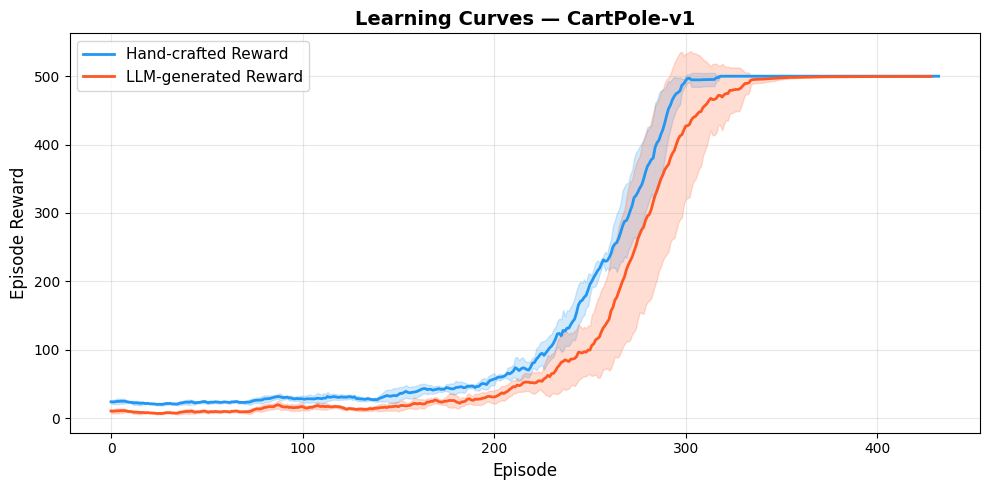

💾 Saved: results/curve_LunarLander_v3.png


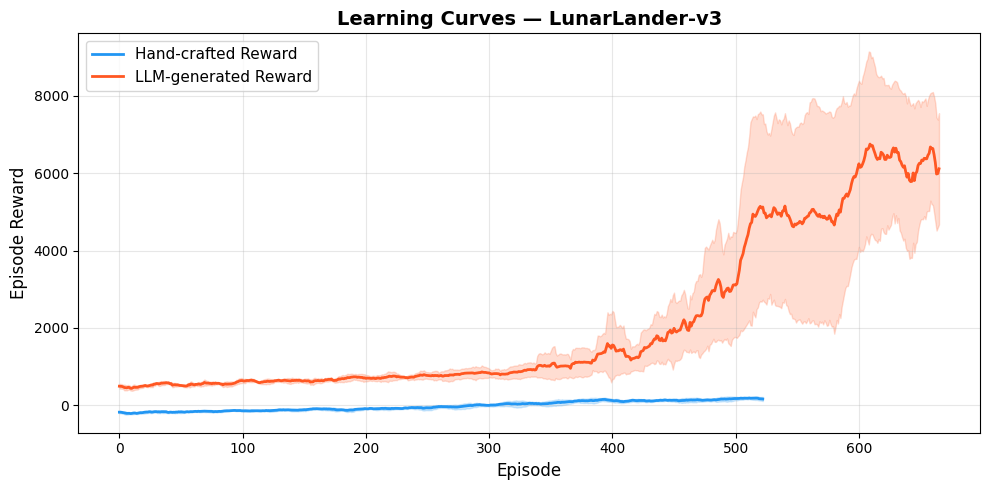

💾 Saved: results/curve_MountainCar_v0.png


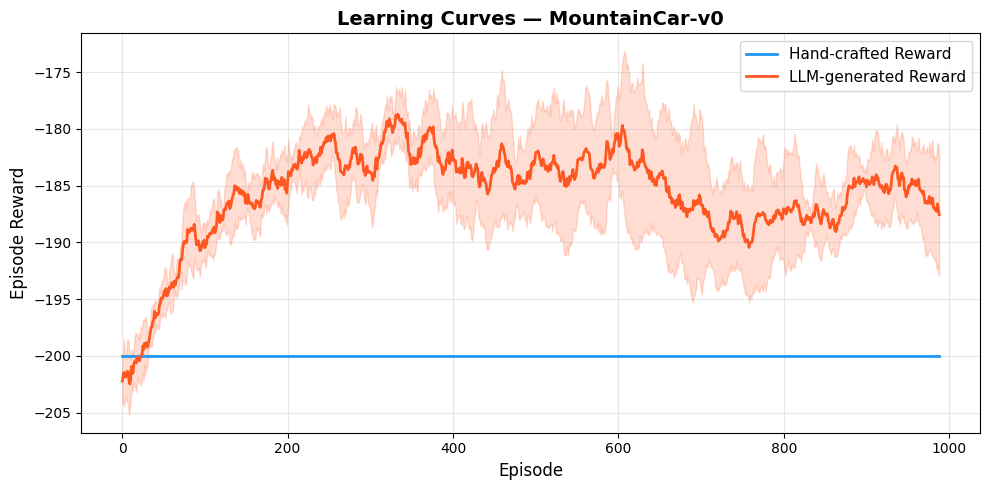

In [12]:
# ── Cell 10: Plot learning curves ────────────────────────────────────────────
def plot_learning_curves(env_id, baseline_rewards, llm_rewards, save=True):
    fig, ax = plt.subplots(figsize=(10, 5))

    def plot_band(all_rewards, color, label):
        smoothed   = [smooth(r, window=15) for r in all_rewards if len(r) > 15]
        if not smoothed:
            return
        min_len    = min(len(r) for r in smoothed)
        arr        = np.array([r[:min_len] for r in smoothed])
        mean       = arr.mean(axis=0)
        std        = arr.std(axis=0)
        x          = np.arange(min_len)
        ax.plot(x, mean, color=color, label=label, linewidth=2)
        ax.fill_between(x, mean - std, mean + std, alpha=0.2, color=color)

    plot_band(baseline_rewards, color="#2196F3", label="Hand-crafted Reward")
    plot_band(llm_rewards,      color="#FF5722", label="LLM-generated Reward")

    ax.set_title(f"Learning Curves — {env_id}", fontsize=14, fontweight="bold")
    ax.set_xlabel("Episode",              fontsize=12)
    ax.set_ylabel("Episode Reward",       fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()

    if save:
        path = f"results/curve_{env_id.replace('-','_')}.png"
        plt.savefig(path, dpi=150, bbox_inches="tight")
        print(f"💾 Saved: {path}")
    plt.show()

for env_id in baseline_results:
    plot_learning_curves(
        env_id,
        baseline_results[env_id],
        llm_results.get(env_id, [])
    )

In [13]:
# ── Cell 11: Summary stats table ─────────────────────────────────────────────
def get_stats(all_rewards, last_n=10):
    """Get mean/std of final performance across seeds."""
    finals = []
    for rewards in all_rewards:
        if len(rewards) >= last_n:
            finals.append(np.mean(rewards[-last_n:]))
        elif rewards:
            finals.append(np.mean(rewards))
    if not finals:
        return 0.0, 0.0
    return np.mean(finals), np.std(finals)

rows = []
for env_id in baseline_results:
    b_mean, b_std = get_stats(baseline_results[env_id])
    l_mean, l_std = get_stats(llm_results.get(env_id, []))
    delta         = l_mean - b_mean
    winner        = "🟢 LLM" if delta > 0 else "🔴 Baseline"
    rows.append({
        "Environment"       : env_id,
        "Baseline (mean±std)": f"{b_mean:.1f} ± {b_std:.1f}",
        "LLM (mean±std)"    : f"{l_mean:.1f} ± {l_std:.1f}",
        "Δ Performance"     : f"{delta:+.1f}",
        "Winner"            : winner,
    })

df = pd.DataFrame(rows)
print("\n📊 Summary Results Table")
print("="*75)
print(df.to_string(index=False))
print("="*75)
df.to_csv("results/summary_table.csv", index=False)
print("💾 Saved: results/summary_table.csv")


📊 Summary Results Table
   Environment Baseline (mean±std)  LLM (mean±std) Δ Performance     Winner
   CartPole-v1         500.0 ± 0.0     499.6 ± 0.1          -0.4 🔴 Baseline
LunarLander-v3        136.8 ± 64.2 7456.7 ± 1011.5       +7319.8      🟢 LLM
MountainCar-v0        -200.0 ± 0.0    -187.0 ± 6.4         +13.0      🟢 LLM
💾 Saved: results/summary_table.csv


In [14]:
# ── Cell 11b: Investigate LunarLander anomaly ────────────────────────────────
print("🔍 LunarLander LLM reward code:")
print(llm_codes.get("LunarLander-v3", "Not found"))

# Check if it could be reward hacking
print("\n📊 LunarLander LLM per-seed final rewards:")
for i, seed_rewards in enumerate(llm_results["LunarLander-v3"]):
    if seed_rewards:
        print(f"  Seed {i}: last 5 episodes = {[round(r,1) for r in seed_rewards[-5:]]}")

🔍 LunarLander LLM reward code:
def custom_reward(obs, action, default_reward, next_obs, done, info):
    reward = default_reward
    # Reward for being upright (angle close to 0)
    reward += (1.0 - abs(next_obs[4])) * 5.0
    # Reward for low angular velocity
    reward += (1.0 - abs(next_obs[5])) * 1.0
    # Reward for low horizontal velocity
    reward += (1.0 - abs(next_obs[2])) * 2.0
    # Reward for being centered horizontally (x position close to 0)
    reward += (1.0 - abs(next_obs[0])) * 2.0
    return reward

📊 LunarLander LLM per-seed final rewards:
  Seed 0: last 5 episodes = [np.float32(8429.3), np.float32(8979.0), np.float32(8245.7), np.float32(7841.9), np.float32(7747.1)]
  Seed 1: last 5 episodes = [np.float32(5075.2), np.float32(2379.5), np.float32(1505.4), np.float32(1414.1), np.float32(8798.4)]
  Seed 2: last 5 episodes = [np.float32(8569.1), np.float32(8784.1), np.float32(8882.6), np.float32(8989.4), np.float32(1303.4)]
  Seed 3: last 5 episodes = [np.float32(8381.

In [ ]:
# ── Cell 12: Failure mode analysis ───────────────────────────────────────────
# This is what makes your project Type 1 — a systematic analysis of
# HOW and WHY the LLM reward functions succeed or fail

FAILURE_TAXONOMY = {
    "reward_hacking"        : "Agent exploits reward without solving the task",
    "incomplete_spec"       : "Reward misses important aspects of the task",
    "wrong_state_variables" : "Reward uses irrelevant or wrongly-scaled obs",
    "magnitude_mismatch"    : "Reward scale too large/small vs default reward",
    "correct"               : "Reward works as intended",
}

def analyze_reward_fn(env_id, code, baseline_mean, llm_mean):
    """
    Print a structured analysis of a generated reward function.
    You fill in the 'observed_failure' field manually after reviewing results.
    """
    print(f"\n{'='*55}")
    print(f"🔍 Failure Mode Analysis: {env_id}")
    print(f"{'='*55}")
    print(f"\n📝 Generated Code:\n{code}\n")
    print(f"📊 Baseline mean: {baseline_mean:.1f}")
    print(f"📊 LLM mean:      {llm_mean:.1f}")
    print(f"📊 Delta:         {llm_mean - baseline_mean:+.1f}")
    print(f"\n🏷️  Failure Taxonomy:")
    for k, v in FAILURE_TAXONOMY.items():
        print(f"   [{k}]: {v}")
    print(f"\n⚠️  Manually classify this reward function using the taxonomy above")
    print(f"    and add your notes to results/failure_analysis.txt")

for env_id in baseline_results:
    b_mean, _ = get_stats(baseline_results[env_id])
    l_mean, _ = get_stats(llm_results.get(env_id, []))
    code       = llm_codes.get(env_id, "N/A")
    analyze_reward_fn(env_id, code, b_mean, l_mean)


🔍 Failure Mode Analysis: CartPole-v1

📝 Generated Code:
def custom_reward(obs, action, default_reward, next_obs, done, info):
    # Penalize based on pole angle and cart position deviation
    # Normalize deviations to be between 0 and 1
    angle_deviation_norm = abs(obs[2]) / 0.418
    position_deviation_norm = abs(obs[0]) / 4.8

    # Reward is higher when deviations are smaller (closer to 0)
    # Use a weighted sum, pole angle is usually more critical for CartPole
    reward = 1.0 - (0.7 * angle_deviation_norm + 0.3 * position_deviation_norm)

    # If the episode is done, it means failure, so give a zero reward for the final step
    if done:
        reward = 0.0
        
    return reward

📊 Baseline mean: 500.0
📊 LLM mean:      496.0
📊 Delta:         -4.0

🏷️  Failure Taxonomy:
   [reward_hacking]: Agent exploits reward without solving the task
   [incomplete_spec]: Reward misses important aspects of the task
   [wrong_state_variables]: Reward uses irrelevant or wrongly-scaled

In [15]:
# ── Cell 13: Prompt variation experiment ─────────────────────────────────────
CARTPOLE_PROMPTS = {
    "vague": """
Write a reward function for CartPole-v1.
The observation has 4 values: cart position, velocity, pole angle, angular velocity.
Function signature: def custom_reward(obs, action, default_reward, next_obs, done, info):
Return a float. No imports.
""",
    "detailed": PROMPTS["CartPole-v1"],
    "with_hint": """
Write a complete Python reward function for CartPole-v1.

Observation:
  obs[0] = cart position   (-4.8 to 4.8, keep near 0)
  obs[1] = cart velocity
  obs[2] = pole angle      (-0.418 to 0.418, keep near 0)
  obs[3] = angular velocity

HINT: penalize large pole angles and large cart displacements.

Use EXACTLY this signature:
def custom_reward(obs, action, default_reward, next_obs, done, info):
Return a float. No imports. No docstrings. Under 10 lines.
""",
}

variation_results = {}

for prompt_type, prompt_text in CARTPOLE_PROMPTS.items():
    print(f"\n{'='*55}")
    print(f"🔬 Prompt type: [{prompt_type}]")
    reward_fn, code = get_llm_reward_function("CartPole-v1", prompt_text)
    if reward_fn is None:
        print(f"  ⚠️  Skipping [{prompt_type}] — reward fn failed")
        variation_results[prompt_type] = {"results": [], "code": code}
        continue

    results = run_experiment(
        "CartPole-v1", 100_000,
        reward_fn = reward_fn,
        label     = f"prompt_{prompt_type}",
        seeds     = [0, 1, 2]
    )
    variation_results[prompt_type] = {"results": results, "code": code}
    m, s = get_stats(results)
    print(f"  ✅ Mean final reward: {m:.1f} ± {s:.1f}")

    # ── Save after every prompt in case of crash ──────────────────────────
    with open("results/variation_results.pkl", "wb") as f:
        pickle.dump(variation_results, f)
    print(f"  💾 Saved checkpoint after [{prompt_type}]")

print("\n✅ All prompt variations done!")


🔬 Prompt type: [vague]

🤖 Requesting reward function for CartPole-v1 via Gemini...
📝 Full raw response (2287 chars):
----------------------------------------
def custom_reward(obs, action, default_reward, next_obs, done, info):
    # Start with the default reward provided by the environment.
    # For CartPole, this is typically +1 for each step until the episode terminates.
    # It is 0 when done.
    reward = default_reward

    # Define thresholds for CartPole-v1 based on environment limits.
    # These are approximate values from the CartPole environment source code.
    # Pole angle threshold: 12 degrees = 0.20943951 radians.
    # Cart position threshold: 2.4 units.
    POLE_ANGLE_THRESHOLD = 0.2095
    CART_POSITION_THRESHOLD = 2.4

    # If the episode is terminated ('done' is True)
    if done:
        # Check if the termination was due to failure (pole fell or cart went out of bounds).
        # We use next_obs to check the state that caused termination.
        # next_obs[

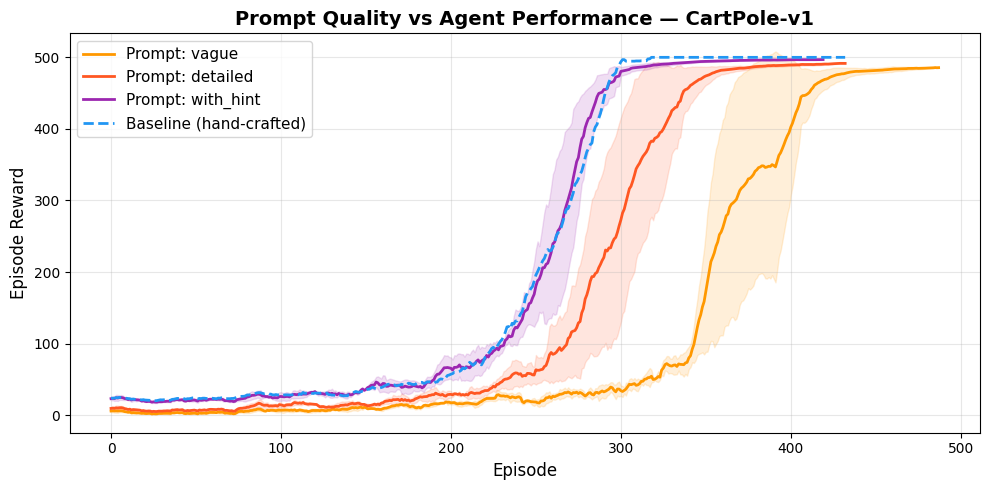

💾 Saved: results/prompt_variation.png


In [16]:
# ── Cell 14: Plot prompt variation results ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
colors  = {"vague": "#FF9800", "detailed": "#FF5722", "with_hint": "#9C27B0"}

for prompt_type, data in variation_results.items():
    smoothed = [smooth(r, 15) for r in data["results"] if len(r) > 15]
    if not smoothed:
        continue
    min_len  = min(len(r) for r in smoothed)
    arr      = np.array([r[:min_len] for r in smoothed])
    mean     = arr.mean(axis=0)
    std      = arr.std(axis=0)
    x        = np.arange(min_len)
    ax.plot(x, mean, label=f"Prompt: {prompt_type}",
            color=colors[prompt_type], linewidth=2)
    ax.fill_between(x, mean-std, mean+std, alpha=0.15, color=colors[prompt_type])

# Also plot baseline
b_smoothed = [smooth(r, 15) for r in baseline_results["CartPole-v1"] if len(r) > 15]
min_len    = min(len(r) for r in b_smoothed)
arr        = np.array([r[:min_len] for r in b_smoothed])
ax.plot(np.arange(min_len), arr.mean(axis=0),
        label="Baseline (hand-crafted)", color="#2196F3",
        linewidth=2, linestyle="--")

ax.set_title("Prompt Quality vs Agent Performance — CartPole-v1",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Episode", fontsize=12)
ax.set_ylabel("Episode Reward", fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("results/prompt_variation.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Saved: results/prompt_variation.png")

In [19]:
# ── Cell 15: Save everything and local download ────────────────────────────
import os
import shutil

# Make sure all results are saved
os.makedirs("results", exist_ok=True)

# Save anything not yet saved
with open("results/baseline_results.pkl", "wb") as f:
    pickle.dump(baseline_results, f)
with open("results/llm_results.pkl", "wb") as f:
    pickle.dump(llm_results, f)
with open("results/llm_codes.pkl", "wb") as f:
    pickle.dump(llm_codes, f)
if variation_results:
    with open("results/variation_results.pkl", "wb") as f:
        pickle.dump(variation_results, f)

print("✅ All .pkl files saved to results/")
print("Files in results/:")
for f in os.listdir("results"):
    size = os.path.getsize(f"results/{f}")
    print(f"  {f:40s} {size:,} bytes")

# Zip results for download (local environment)
import shutil
zip_path = "project_results"
if os.path.exists(zip_path):
    shutil.rmtree(zip_path)
shutil.make_archive(zip_path, 'zip', '.', 'results')
print(f"\n📦 Zipped! Created: {zip_path}.zip")
print(f"✅ Results ready in: {os.path.abspath('results/')}")

✅ All .pkl files saved to results/
Files in results/:
  baseline_results.pkl                     156,715 bytes
  curve_CartPole_v1.png                    103,873 bytes
  curve_LunarLander_v3.png                 102,186 bytes
  curve_MountainCar_v0.png                 159,213 bytes
  llm_codes.pkl                            1,929 bytes
  llm_results.pkl                          166,210 bytes
  prompt_variation.png                     150,047 bytes
  summary_table.csv                        253 bytes
  variation_results.pkl                    67,445 bytes

📦 Zipped! Created: project_results.zip
✅ Results ready in: c:\Users\patel\Downloads\results
